1. Pull tables
2. Review Data
3. Model Graphs to show flights and weater condition over time
Super spannende Frage! ✈️ Ich gebe dir mal eine kurze, faktenbasierte Übersicht zu **Hurrikan „Superstorm“ Sandy** und den Auswirkungen speziell auf den **Flughafen LaGuardia (LGA)** in New York:

---

## 🌀 Was war Hurrikan Sandy?

* **Datum:** Ende Oktober 2012 (Landfall am 29.10.2012 in New Jersey).
* **Stärke:** Kategorie 1 Hurrikan beim Landfall, aber außergewöhnlich groß (Windfeld über 1.500 km).
* **Besonderheit:** Kombination aus Hurrikan + Kaltfront → extrem hoher **Sturmflut-Effekt**.

---

## 🌊 Auswirkungen auf New York

* Massive **Sturmfluten** überfluteten Teile von Lower Manhattan, Brooklyn und Queens.
* **Stromausfälle** für Millionen Haushalte.
* U-Bahn-Netz in Manhattan wurde geflutet.
* Sachschäden von über **70 Milliarden USD**.

---

## ✈️ Auswirkungen auf LaGuardia Airport (LGA)

LaGuardia ist besonders verwundbar, weil er **direkt am Wasser (Flushing Bay)** liegt.

* Am **29. Oktober 2012** drang die Sturmflut ins Flughafengelände ein.
* **Start- und Landebahnen standen unter Wasser** (vor allem die östliche Runway 13/31).
* Alle **Flüge wurden gestrichen** – mehrere Tage **kompletter Stillstand**.
* Erst **am 1. November 2012** (3 Tage später) nahm LGA den Flugbetrieb wieder schrittweise auf.
* In der Zwischenzeit wurden Flüge auf andere Flughäfen (JFK, Newark) umgeleitet – auch diese hatten aber Einschränkungen.

---

## 📉 Gesamtwirkung

* Über **19.000 Flüge** in der Region wurden gestrichen.
* LGA war **einer der am stärksten betroffenen Flughäfen** in den USA.
* Die Überschwemmung führte dazu, dass später **neue Hochwasserschutzmaßnahmen** für LaGuardia entwickelt wurden (z. B. höhere Barrieren, Pumpensysteme).

---

👉 Fazit:
Superstorm Sandy hat den Flughafen **LaGuardia praktisch lahmgelegt**, weil das Gelände überflutet war. Das war ein Paradebeispiel für die **Verwundbarkeit von Küstenflughäfen** gegenüber Sturmfluten.

---


In [ ]:
!pip install sqlalchemy psycopg2  # For Postgres
!pip install pymysql  # For MySQL
!pip install pyodbc  # For SQL Server


In [3]:
import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

In [4]:
# Let's load values from the .env file
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [5]:
# Now building the URL with the values from the .env file

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

# without specifying the schema default connection is to the schema `public`
# url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'


In [8]:
engine = create_engine(url, echo=True)

In [ ]:
my_schema = 'clear_skies' # update it to your schema

with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {my_schema};'))

In [ ]:
#df_flights
with engine.begin() as conn: # Done with echo=False
    result = conn.execute(text(f'''
                               SELECT * FROM prep_flights; 
                                '''))
    data = result.all()

### Let's create a dataframe out of that
df_flights = pd.DataFrame(data) 
df_flights


In [17]:
# Filter für LGA in origin oder dest
df_lga = df_flights[(df_flights['origin'] == 'LGA') | (df_flights['dest'] == 'LGA')]


In [ ]:
#df_weather_daily
with engine.begin() as conn: # Done with echo=False
    result = conn.execute(text(f'''
                               SELECT * FROM prep_weather_daily; 
                                '''))
    data = result.all()

### Let's create a dataframe out of that
df_weather_daily = pd.DataFrame(data) 
df_weather_daily

In [ ]:
#df_weather_hourly
with engine.begin() as conn: # Done with echo=False
    result = conn.execute(text(f'''
                               SELECT * FROM prep_weather_hourly; 
                                '''))
    data = result.all()

### Let's create a dataframe out of that
df_weather_hourly = pd.DataFrame(data) 
df_weather_hourly

In [18]:
#SEE COLUMNS
print("df_lga columns:", sorted(df_flights.columns))
print("df_weather_hourly columns:", sorted(df_weather_hourly.columns))
print("df_weather_daily columns:", sorted(df_weather_daily.columns))

df_lga columns: ['actual_elapsed_time', 'actual_elapsed_time_interval', 'air_time', 'air_time_interval', 'airline', 'arr_delay', 'arr_delay_interval', 'arr_time', 'cancelled', 'dep_delay', 'dep_delay_interval', 'dep_time', 'dest', 'distance_km', 'diverted', 'flight_date', 'flight_number', 'origin', 'sched_arr_time', 'sched_dep_time', 'tail_number']
df_weather_hourly columns: ['airport_code', 'condition_code', 'cw', 'date', 'date_day', 'date_month', 'date_year', 'day_part', 'dewpoint_c', 'hour', 'humidity_perc', 'month_name', 'precipitation_mm', 'pressure_hpa', 'snow_mm', 'station_id', 'sun_minutes', 'temp_c', 'time', 'timestamp', 'weekday', 'wind_direction', 'wind_peakgust_kmh', 'wind_speed_kmh']
df_weather_daily columns: ['airport_code', 'avg_peakgust', 'avg_pressure_hpa', 'avg_temp_c', 'avg_wind_direction', 'avg_wind_speed', 'cw', 'date', 'date_day', 'date_month', 'date_year', 'max_snow_mm', 'max_temp_c', 'min_temp_c', 'month_name', 'precipitation_mm', 'season', 'station_id', 'sun_mi

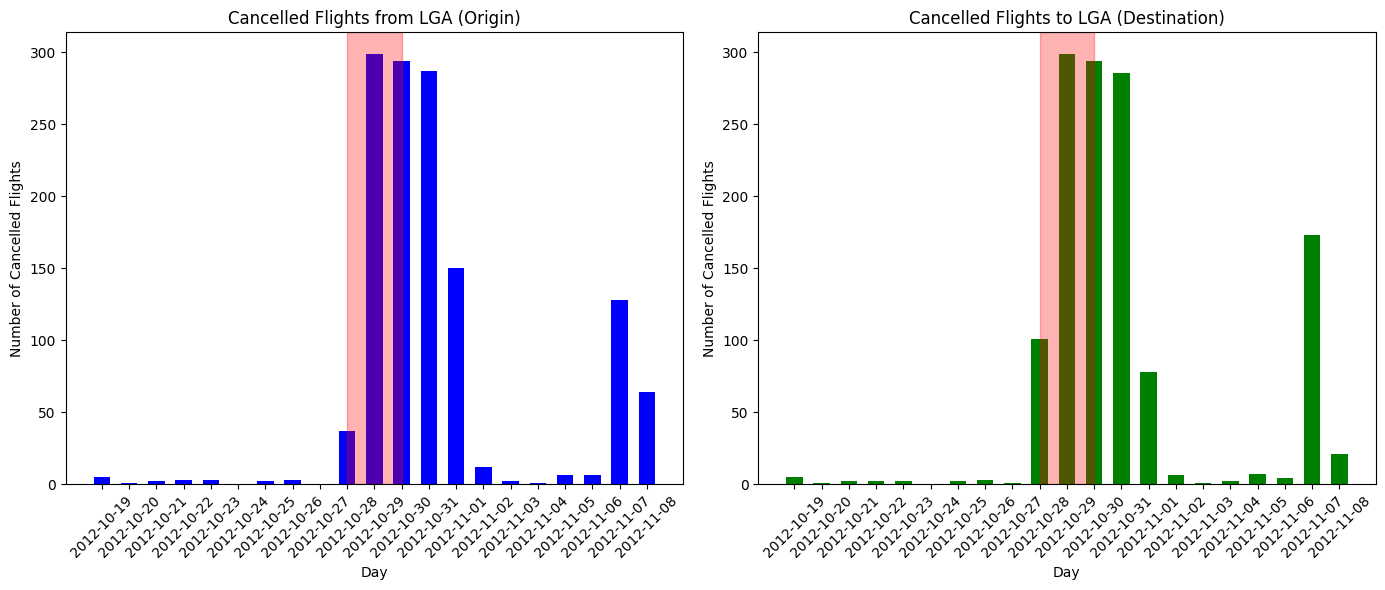

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Zeitraum definieren
ref_date = pd.to_datetime('2012-10-29')
start_date = ref_date - pd.Timedelta(days=10)
end_date = ref_date + pd.Timedelta(days=10)



# Alle Tage als DataFrame
all_days = pd.DataFrame({'day': pd.date_range(start=start_date, end=end_date)})

# Filter gecancelte Flüge
origin_lga_cancelled = df_flights[(df_flights['origin'] == 'LGA') & (df_flights['cancelled'] == 1)]
dest_lga_cancelled = df_flights[(df_flights['dest'] == 'LGA') & (df_flights['cancelled'] == 1)]

# Count pro Tag (day als datetime64)
origin_counts = origin_lga_cancelled.groupby(origin_lga_cancelled['flight_date'].dt.normalize()).size().reset_index(name='count')
origin_counts.rename(columns={'flight_date': 'day'}, inplace=True)

dest_counts = dest_lga_cancelled.groupby(dest_lga_cancelled['flight_date'].dt.normalize()).size().reset_index(name='count')
dest_counts.rename(columns={'flight_date': 'day'}, inplace=True)

# Merge mit allen Tagen und NaN durch 0 ersetzen
origin_counts = pd.merge(all_days, origin_counts, on='day', how='left').fillna(0)
dest_counts = pd.merge(all_days, dest_counts, on='day', how='left').fillna(0)

# Plot
plt.figure(figsize=(14,6))

# Origin LGA
plt.subplot(1,2,1)
plt.bar(origin_counts['day'], origin_counts['count'], width=0.6, color='blue')
plt.title('Cancelled Flights from LGA (Origin)')
plt.xlabel('Day')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(origin_counts['day'], rotation=45)  # Alle Tage anzeigen

# Sandy markieren (28.–30. Okt)
plt.axvspan(pd.to_datetime("2012-10-28"), pd.to_datetime("2012-10-30"), 
            color='red', alpha=0.3, label='Hurricane Sandy')

# Destination LGA
plt.subplot(1,2,2)
plt.bar(dest_counts['day'], dest_counts['count'], width=0.6, color='green')
plt.title('Cancelled Flights to LGA (Destination)')
plt.xlabel('Day')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(dest_counts['day'], rotation=45)  # Alle Tage anzeigen

# Sandy markieren (28.–30. Okt)
plt.axvspan(pd.to_datetime("2012-10-28"), pd.to_datetime("2012-10-30"), 
            color='red', alpha=0.3, label='Hurricane Sandy')

plt.tight_layout()
plt.show()



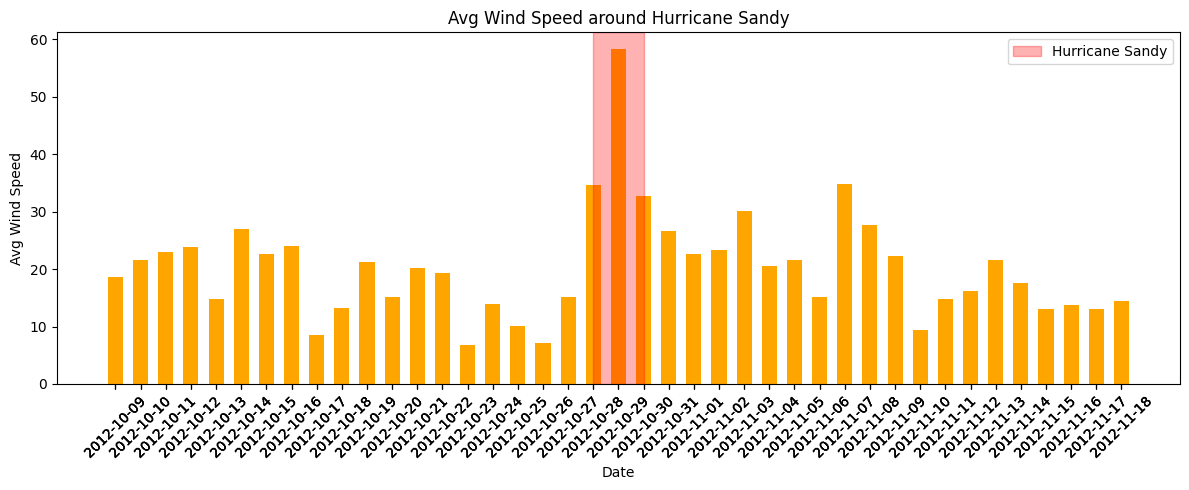

In [53]:
import matplotlib.pyplot as plt

# Zeitraum wie zuvor
ref_date = pd.to_datetime("2012-10-29")
start_date = ref_date - pd.Timedelta(days=20)
end_date = ref_date + pd.Timedelta(days=20)

# Wetterdaten im Zeitraum
df_weather_daily['date'] = pd.to_datetime(df_weather_daily['date'])
weather_period = df_weather_daily[
    (df_weather_daily['date'] >= start_date) &
    (df_weather_daily['date'] <= end_date)
][['date', 'avg_wind_speed']]

# Plot
plt.figure(figsize=(12,5))
plt.bar(weather_period['date'], weather_period['avg_wind_speed'], width=0.6, color='orange')

# Alle Tage sichtbar
plt.xticks(weather_period['date'], rotation=45)
plt.title('Avg Wind Speed around Hurricane Sandy')
plt.xlabel('Date')
plt.ylabel('Avg Wind Speed')

# Sandy markieren (28.–30. Okt)
plt.axvspan(pd.to_datetime("2012-10-28"), pd.to_datetime("2012-10-30"), 
            color='red', alpha=0.3, label='Hurricane Sandy')

plt.legend()
plt.tight_layout()
plt.show()

plt.show()


/var/folders/6q/jbbpf7ln3534rrgvzn52m5lw0000gn/T/ipykernel_2299/1936055311.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  weather_period = weather_period.fillna(0)


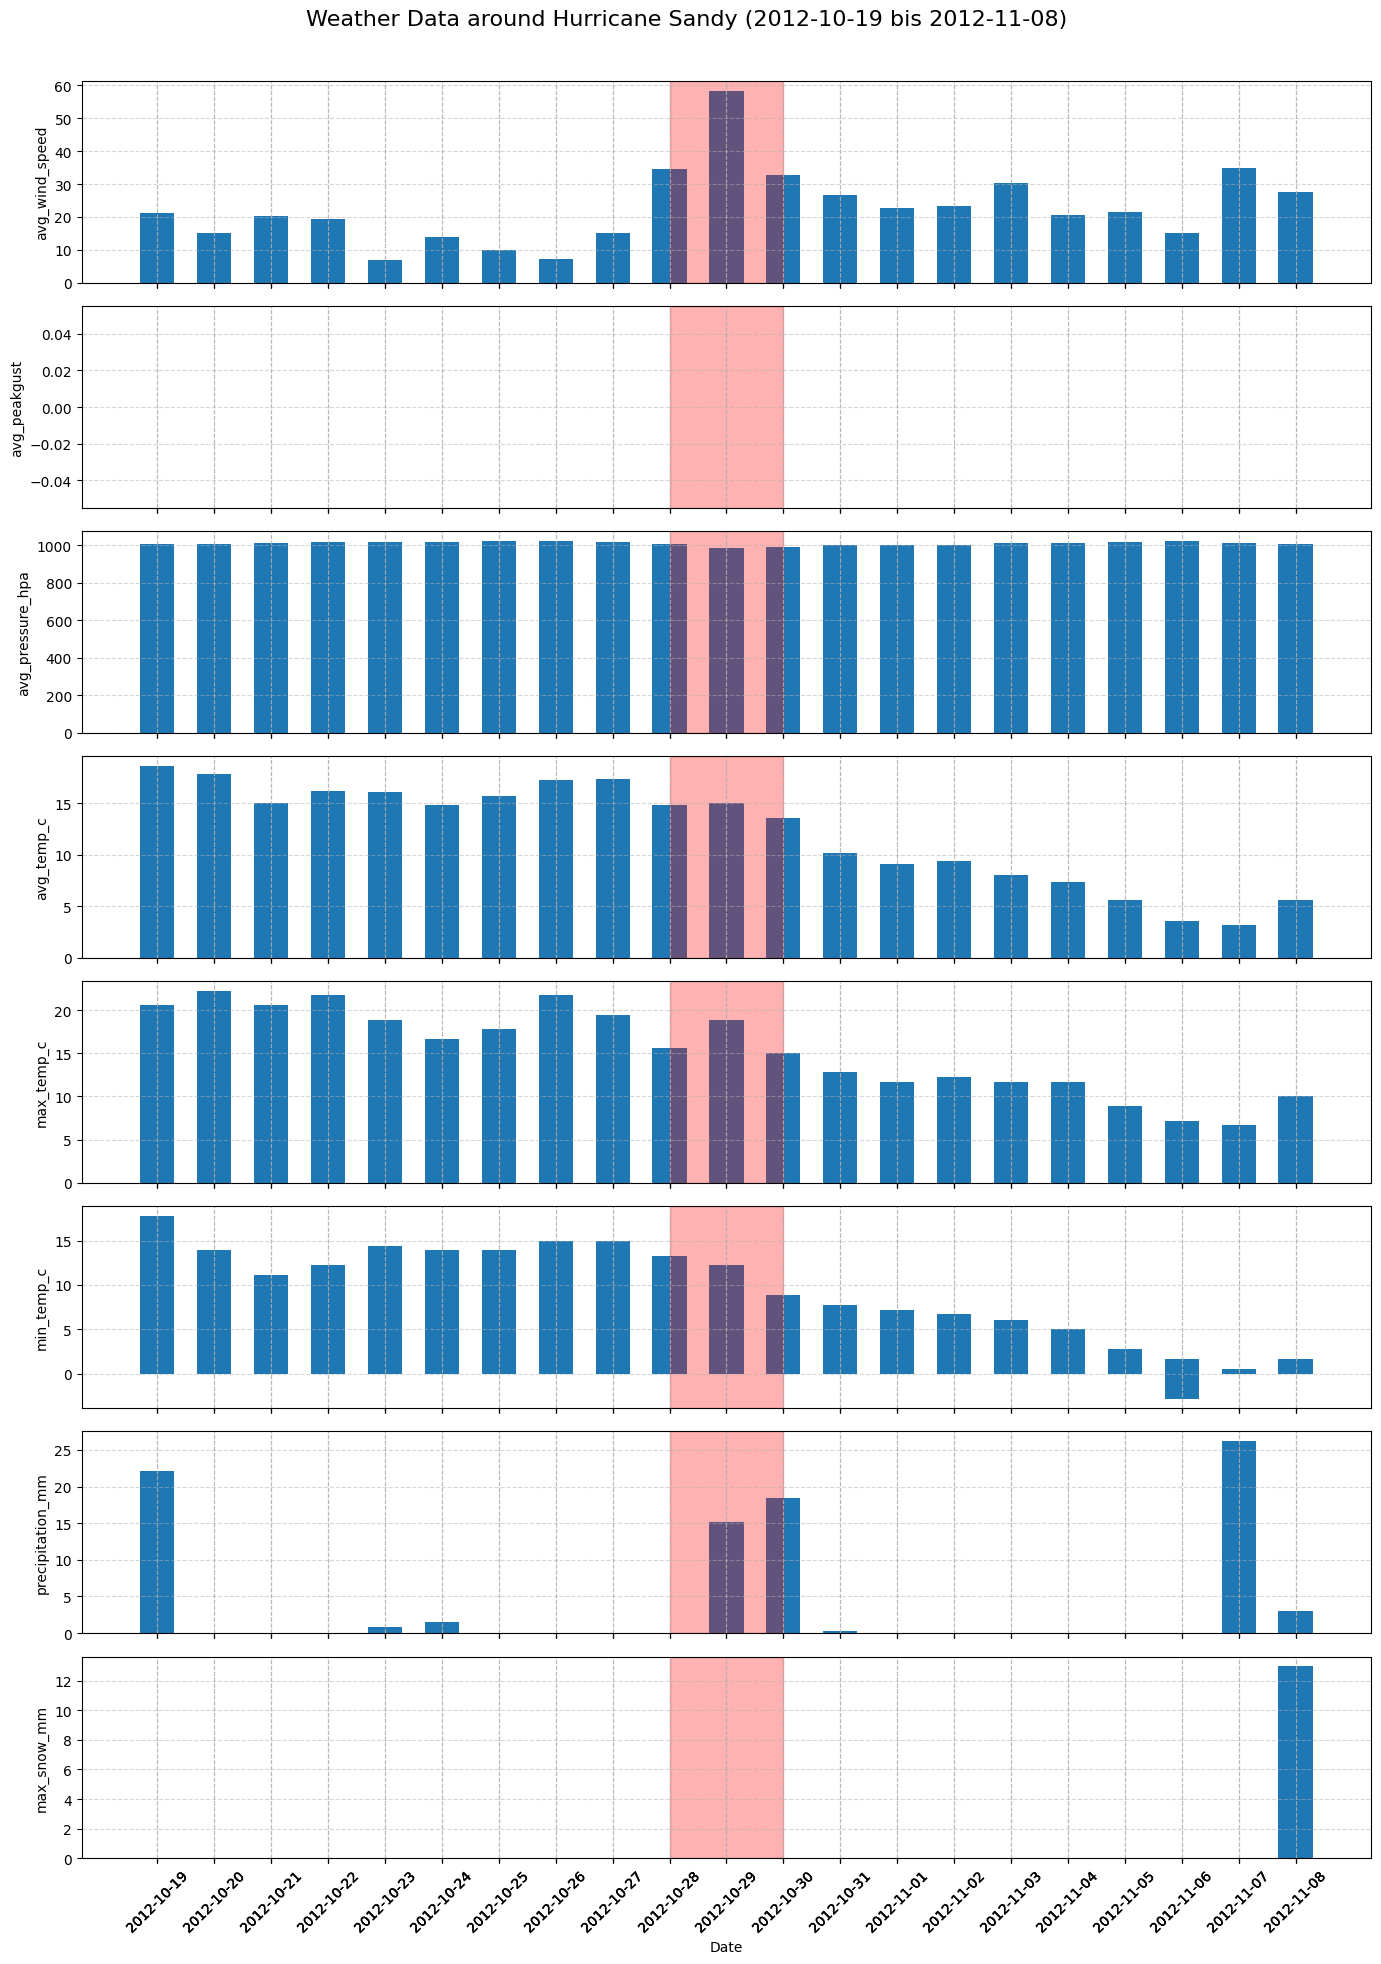

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Zeitraum definieren
ref_date = pd.to_datetime("2012-10-29")
start_date = ref_date - pd.Timedelta(days=10)
end_date = ref_date + pd.Timedelta(days=10)

# Sicherstellen, dass 'date' datetime ist
df_weather_daily['date'] = pd.to_datetime(df_weather_daily['date'])

# Wetter-Spalten auswählen
weather_cols = [
    'avg_wind_speed', 'avg_peakgust', 'avg_pressure_hpa',
    'avg_temp_c', 'max_temp_c', 'min_temp_c',
    'precipitation_mm', 'max_snow_mm'
]

# Zeitraum filtern
weather_period = df_weather_daily[
    (df_weather_daily['date'] >= start_date) &
    (df_weather_daily['date'] <= end_date)
][['date'] + weather_cols].copy()

# Fehlende Werte auffüllen
weather_period = weather_period.fillna(0)

# Plot: mehrere Subplots
fig, axes = plt.subplots(len(weather_cols), 1, figsize=(14, 20), sharex=True)

for i, col in enumerate(weather_cols):
    axes[i].bar(weather_period['date'], weather_period[col], width=0.6)
    axes[i].set_ylabel(col)
    axes[i].axvspan(pd.to_datetime("2012-10-28"), pd.to_datetime("2012-10-30"),
                    color='red', alpha=0.3)
    axes[i].grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel("Date")
plt.xticks(weather_period['date'], rotation=45)
plt.suptitle("Weather Data around Hurricane Sandy (2012-10-19 bis 2012-11-08)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




/var/folders/6q/jbbpf7ln3534rrgvzn52m5lw0000gn/T/ipykernel_2299/1976451112.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lga['flight_date'] = pd.to_datetime(df_lga['flight_date'])


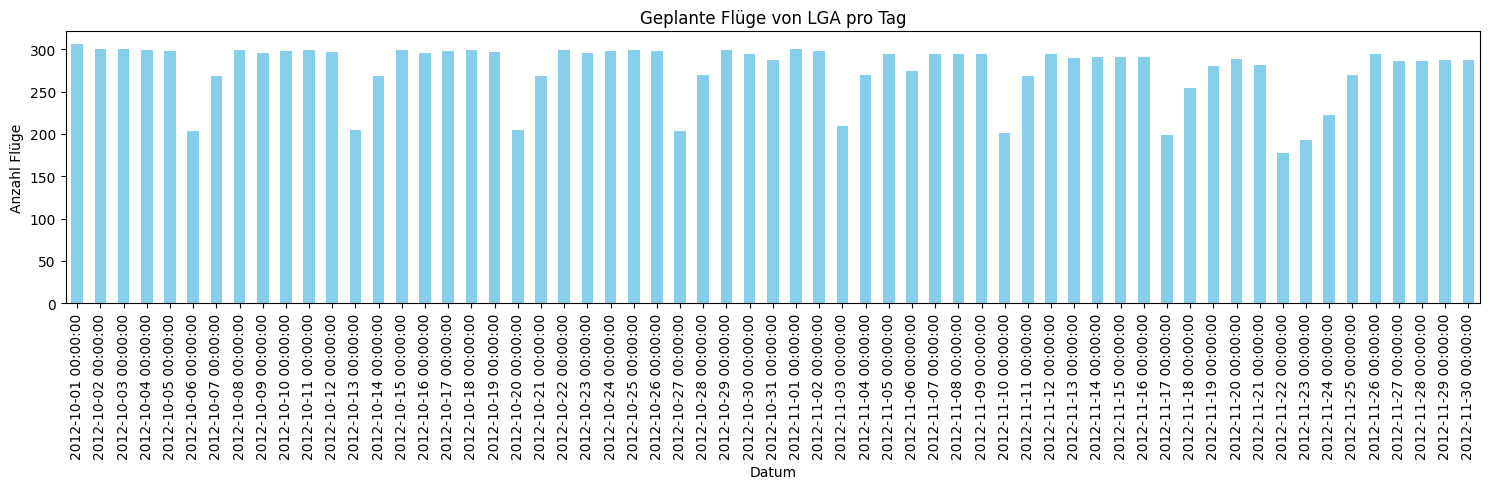

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Sicherstellen, dass 'flight_date' ein datetime-Objekt ist
df_lga['flight_date'] = pd.to_datetime(df_lga['flight_date'])

# Filter: nur Flüge mit Origin LGA
df_lga_origin = df_lga[df_lga['origin'] == 'LGA']

# Zähle Flüge pro Tag
flights_per_day = df_lga_origin.groupby('flight_date').size()

# Alle Tage im Zeitraum erzeugen
all_days = pd.date_range(start=df_lga['flight_date'].min(), end=df_lga['flight_date'].max())

# Fehlende Tage mit 0 Flügen auffüllen
flights_per_day = flights_per_day.reindex(all_days, fill_value=0)

# Balkendiagramm erstellen
plt.figure(figsize=(15,5))
flights_per_day.plot(kind='bar', color='skyblue')
plt.xlabel('Datum')
plt.ylabel('Anzahl Flüge')
plt.title('Geplante Flüge von LGA pro Tag')
plt.xticks(rotation=90)  # Datum lesbar machen
plt.tight_layout()
plt.show()


/var/folders/6q/jbbpf7ln3534rrgvzn52m5lw0000gn/T/ipykernel_2299/3987167433.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lga['flight_date'] = pd.to_datetime(df_lga['flight_date'])


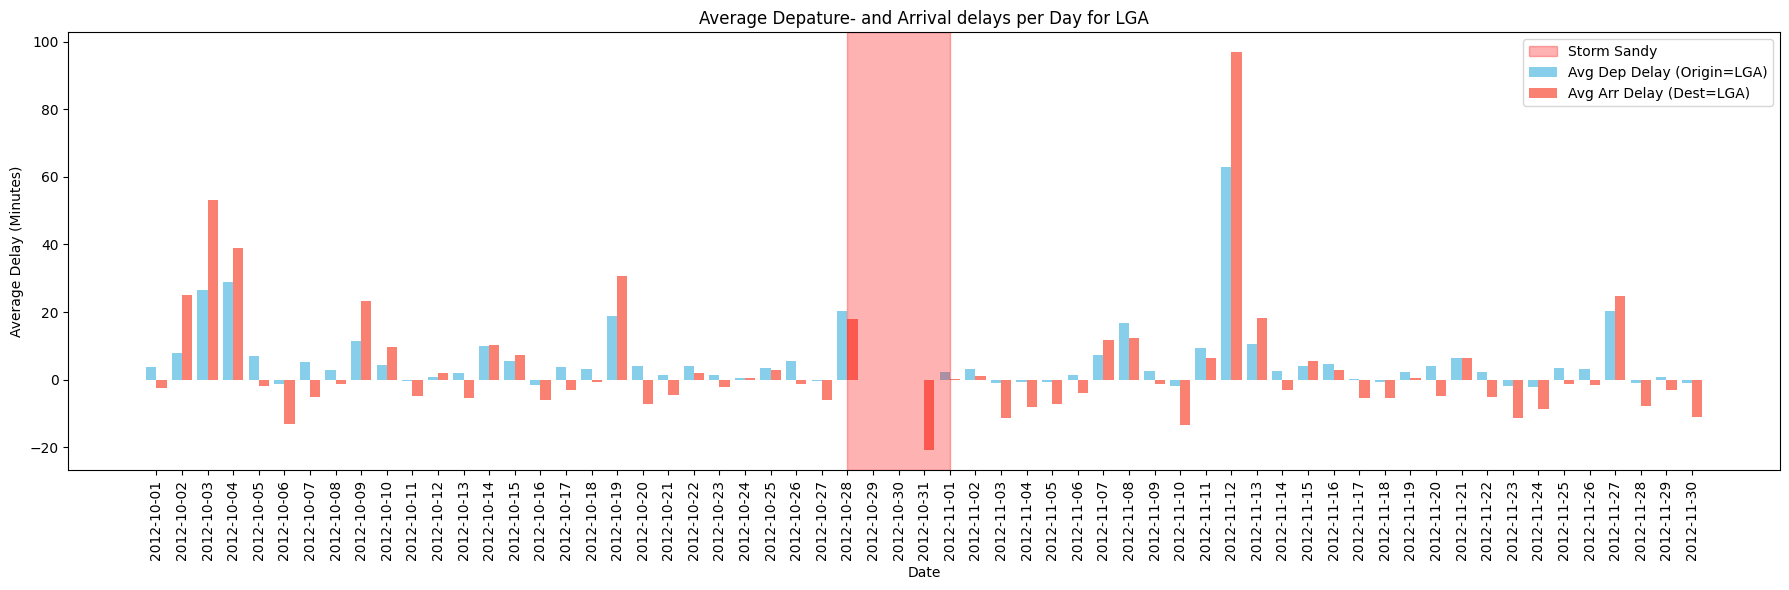

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Sicherstellen, dass 'flight_date' als datetime vorliegt
df_lga['flight_date'] = pd.to_datetime(df_lga['flight_date'])

# Alle Tage im Zeitraum
all_days = pd.date_range(df_lga['flight_date'].min(), df_lga['flight_date'].max())

# Durchschnittliche Abflugverspätung pro Tag (Origin = LGA)
dep_delay_per_day = df_lga[df_lga['origin'] == 'LGA'].groupby('flight_date')['dep_delay'].mean()
dep_delay_per_day = dep_delay_per_day.reindex(all_days, fill_value=0)

# Durchschnittliche Ankunftsverspätung pro Tag (Dest = LGA)
arr_delay_per_day = df_lga[df_lga['dest'] == 'LGA'].groupby('flight_date')['arr_delay'].mean()
arr_delay_per_day = arr_delay_per_day.reindex(all_days, fill_value=0)

# Balkendiagramm erstellen
plt.figure(figsize=(18,6))
width = 0.4  # Breite der Balken
x = range(len(all_days))

plt.bar([i - width/2 for i in x], dep_delay_per_day, width=width, label='Avg Dep Delay (Origin=LGA)', color='skyblue')
plt.bar([i + width/2 for i in x], arr_delay_per_day, width=width, label='Avg Arr Delay (Dest=LGA)', color='salmon')

# Storm Sandy markieren: 28.10.2012 - 01.11.2012
storm_start = pd.to_datetime('2012-10-28')
storm_end   = pd.to_datetime('2012-11-01')
plt.axvspan(
    (storm_start - all_days[0]).days, 
    (storm_end - all_days[0]).days, 
    color='red', alpha=0.3, label='Storm Sandy'
)

plt.xlabel('Date')
plt.ylabel('Average Delay (Minutes)')
plt.title('Average Depature- and Arrival delays per Day for LGA')
plt.xticks(x, [d.strftime('%Y-%m-%d') for d in all_days], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


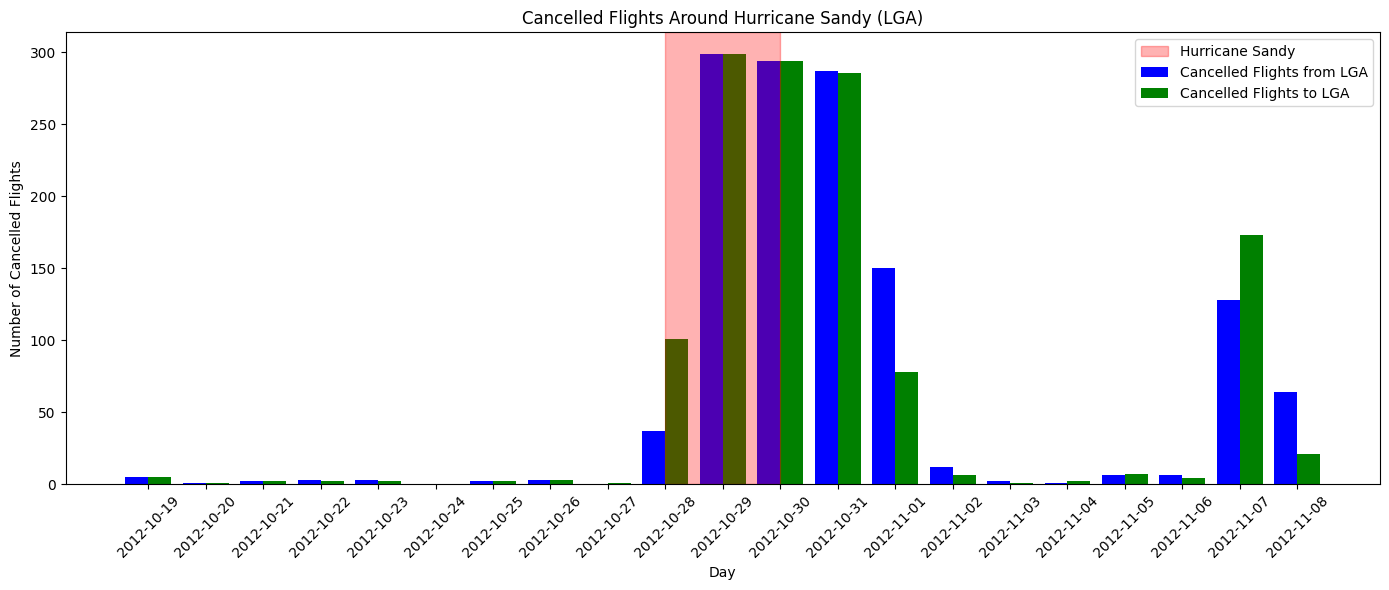

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Zeitraum definieren
ref_date = pd.to_datetime('2012-10-29')
start_date = ref_date - pd.Timedelta(days=10)
end_date = ref_date + pd.Timedelta(days=10)

# Alle Tage als DataFrame
all_days = pd.DataFrame({'day': pd.date_range(start=start_date, end=end_date)})

# Filter gecancelte Flüge
origin_lga_cancelled = df_flights[(df_flights['origin'] == 'LGA') & (df_flights['cancelled'] == 1)]
dest_lga_cancelled = df_flights[(df_flights['dest'] == 'LGA') & (df_flights['cancelled'] == 1)]

# Count pro Tag
origin_counts = origin_lga_cancelled.groupby(origin_lga_cancelled['flight_date'].dt.normalize()).size().reset_index(name='origin_count')
origin_counts.rename(columns={'flight_date': 'day'}, inplace=True)

dest_counts = dest_lga_cancelled.groupby(dest_lga_cancelled['flight_date'].dt.normalize()).size().reset_index(name='dest_count')
dest_counts.rename(columns={'flight_date': 'day'}, inplace=True)

# Merge mit allen Tagen und NaN durch 0 ersetzen
merged_counts = pd.merge(all_days, origin_counts, on='day', how='left').fillna(0)
merged_counts = pd.merge(merged_counts, dest_counts, on='day', how='left').fillna(0)

# Plot
plt.figure(figsize=(14,6))
width = 0.4
x = range(len(merged_counts))

plt.bar([i - width/2 for i in x], merged_counts['origin_count'], width=width, color='blue', label='Cancelled Flights from LGA')
plt.bar([i + width/2 for i in x], merged_counts['dest_count'], width=width, color='green', label='Cancelled Flights to LGA')

# Sandy markieren (28.–30. Okt)
storm_start = pd.to_datetime("2012-10-28")
storm_end   = pd.to_datetime("2012-10-30")
plt.axvspan((storm_start - merged_counts['day'].min()).days, 
            (storm_end - merged_counts['day'].min()).days, 
            color='red', alpha=0.3, label='Hurricane Sandy')

plt.xticks(x, merged_counts['day'].dt.strftime('%Y-%m-%d'), rotation=45)
plt.xlabel('Day')
plt.ylabel('Number of Cancelled Flights')
plt.title('Cancelled Flights Around Hurricane Sandy (LGA)')
plt.legend()
plt.tight_layout()
plt.show()
